# Assignment 3: Linear Models

**Q1.** Please answer the following questions in your own words.

1. What makes a model "linear"? "Linear" in what?
2. How do you interpret the coefficient for a dummy/one-hot-encoded variable? (Hint: how do you handle the intercept of the model?)
3. Can linear regression be used for classification? Explain why, or why not.
4. What are signs that your linear model is over-fitting?
5. Clearly explain multi-colinearity using the two-stage least squares technique.
6. How can you incorporate nonlinear relationships between your target/response/dependent/outcome variable $y$ and your features/control/response/independent variables $x$ into your analysis?
7. What is the interpretation of the slope coefficient in a linear regression?
8. Compare the train/test split and $k$-fold cross validation.
9. How is the $k$ in $k$-fold cross validation typically selected?

**Answers**
1. A model is linear if its coefficients just multiply the inputs and get added together. So for example, if its not a straight line relationship between two variables, then it is not linear. Additionally, if the effect of one variable on another is not constant, and changes depending on a varaible then it's not linear. 
2. This coefficient just shows how much the outcome changes when the variable goes from 0 to 1. The coefficient is basically the difference between how much higher or lower a variable is when the dummy is 1 compared to 0 since the intercept is the baseline when the dummy variable is 0. 
3. Linear regression can be used, however, it's not the best idea. It can give values that don't make sense in probabilities such as less than 0 or greater than 1. 
4. Basically when there is a lot of extra noise instead of patterns. Thus, if it does well on training data but not so great on test data, that is a big sign. 
5. This is where variables are very highly correlated, making it difficult to distinguish each of their effects. For 2SLS, we predict one of those variables using the other, then use that predicted version in the main model. This way, we can reduce the issue of the variables being too correlated. 
6. To incorporate non-linear relationships, we can add terms that let the model capture more complex patterns such as squared terms or logs. 
7. In a linear regression, between just x and y, the slope tells us how much y changes when x increases by 1. It shows us how strong the relationship is between the two variables. 
8. Train and test split only splits the data once, so the results can depend on that one split. In terms of k-fold cross validation, it splits multiple times and then averages the results, making it more trustworthy.
9. There are a few defaults that people use such as 5 or 10, but there a few trade-offs with going higher or lower. When the k value is smaller, it is faster but not as stable. As for a bigger k value, it is more accurate but is not as fast. 

**Q2.** Load `./data/Q1_clean.csv`. The data include

- `Price` per night
- `Review Scores Rating`: The average rating for the property
- `Neighbourhood`: The bourough of NYC. Note the space, or rename the variable.

1. Compute the average prices and scores by `Neighbourhood`; which bourough is the most expensive on average? Create a kernel density plot of price and log price, grouping by `Neighbourhood`.
2. Regress price on `Neighbourhood` by creating the appropriate dummy/one-hot-encoded variables (Are you dropping the first category, or the intercept of the regresssion?). Compare the coefficients in the regression to the table from part 1 (the answer depends on how you handled the dummy variable trap). How are the conditional group means and the estimated coefficients related?
3. Regress price on `Review Scores Rating` and a constant/intercept. Interpret the slope coefficient clearly in words.
4. Regress price on both `Neighbourhood` and `Review Scores Rating`. How does the slope coefficient on `Review Scores Rating` change? How do the neighborhood averages change?
5. Here is a puzzle: Regress price on a constant, and a separate slope coefficient for each neighborhood for `Review Scores Rating`. Are the slopes similar across neighborhoods, or not?
6. Use cross validation to evaluate the models from parts 4, 5, and 6.

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import statsmodels.api as sm
import statsmodels.formula.api as smf


df = pd.read_csv("./data/Q1_clean.csv")

                     Price  Review Scores Rating
Neighbourhood                                   
Bronx            75.276498             91.654378
Brooklyn        127.747378             92.363497
Manhattan       183.664286             91.801496
Queens           96.857233             91.549057
Staten Island   146.166667             90.843750
Most expensive:  Manhattan


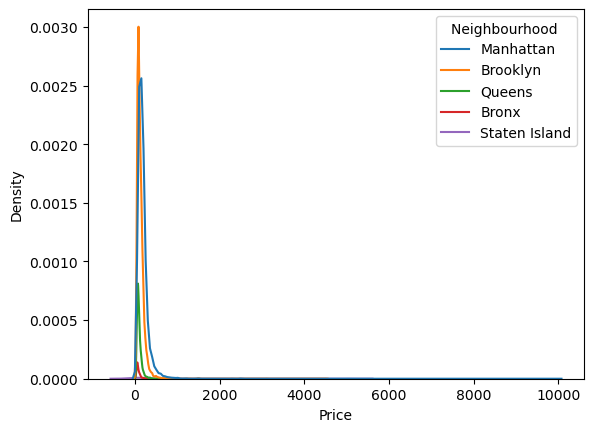

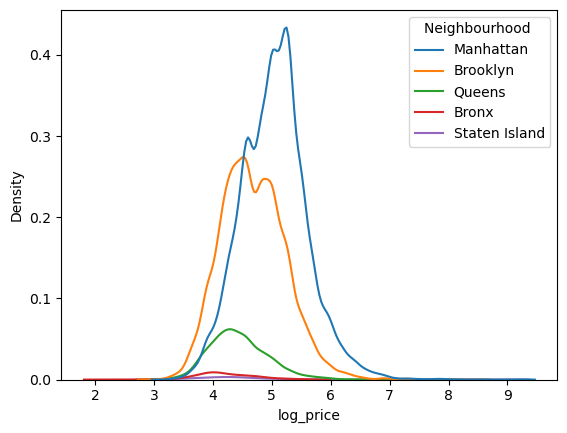

In [9]:
means = df.groupby("Neighbourhood ")[["Price", "Review Scores Rating"]].mean()
print(means)
print("Most expensive: ", means["Price"].idxmax())
sns.kdeplot(data=df, x="Price", hue="Neighbourhood ")
plt.show()
df["log_price"] = np.log(df["Price"])
sns.kdeplot(data=df, x="log_price", hue="Neighbourhood ")
plt.show()

In [14]:
df.columns = df.columns.str.strip()
dum = smf.ols("Price ~ C(Neighbourhood)", data=df).fit()
print(dum.summary())

                            OLS Regression Results                            
Dep. Variable:                  Price   R-squared:                       0.046
Model:                            OLS   Adj. R-squared:                  0.046
Method:                 Least Squares   F-statistic:                     268.9
Date:                Wed, 18 Mar 2026   Prob (F-statistic):          4.43e-226
Time:                        19:34:28   Log-Likelihood:            -1.4174e+05
No. Observations:               22153   AIC:                         2.835e+05
Df Residuals:                   22148   BIC:                         2.835e+05
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                                        coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------------------------
Interc

In [18]:
df = df.rename(columns={"Review Scores Rating": "Rating"})
PoR = smf.ols("Price ~ Rating", data=df).fit()
print(PoR.summary())

                            OLS Regression Results                            
Dep. Variable:                  Price   R-squared:                       0.004
Model:                            OLS   Adj. R-squared:                  0.004
Method:                 Least Squares   F-statistic:                     81.92
Date:                Wed, 18 Mar 2026   Prob (F-statistic):           1.53e-19
Time:                        19:36:58   Log-Likelihood:            -1.4222e+05
No. Observations:               22153   AIC:                         2.844e+05
Df Residuals:                   22151   BIC:                         2.845e+05
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     60.8784     10.423      5.841      0.0

Slope coefficient on rating is about 1.02, so for every 1 point increase in review score, the price increases by about $1.02.

In [19]:
PonR = smf.ols("Price ~ C(Neighbourhood) + Rating", data=df).fit()
print(PonR.summary())

                            OLS Regression Results                            
Dep. Variable:                  Price   R-squared:                       0.050
Model:                            OLS   Adj. R-squared:                  0.050
Method:                 Least Squares   F-statistic:                     235.3
Date:                Wed, 18 Mar 2026   Prob (F-statistic):          1.21e-245
Time:                        19:37:28   Log-Likelihood:            -1.4169e+05
No. Observations:               22153   AIC:                         2.834e+05
Df Residuals:                   22147   BIC:                         2.834e+05
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                                        coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------------------------
Interc

When using both neighborhood and rating, the coefficient on rating increases slightly from 1.02 to 1.08. This eans that after controlling for neighborhood, a 1 point increase in rating is correlated to about $1.08 increase in price. As for the neighborhood coefficients, it shows the difference in price relative to the baseline while holding the rating constant.

In [20]:
diff_s = smf.ols("Price ~ C(Neighbourhood) * Rating", data=df).fit()
print(diff_s.summary())

                            OLS Regression Results                            
Dep. Variable:                  Price   R-squared:                       0.068
Model:                            OLS   Adj. R-squared:                  0.067
Method:                 Least Squares   F-statistic:                     178.4
Date:                Wed, 18 Mar 2026   Prob (F-statistic):               0.00
Time:                        19:39:01   Log-Likelihood:            -1.4149e+05
No. Observations:               22153   AIC:                         2.830e+05
Df Residuals:                   22143   BIC:                         2.831e+05
Df Model:                           9                                         
Covariance Type:            nonrobust                                         
                                               coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------------------------

The slopes are not similar aross neighborhoods. This is because the interaction terms are different for each group as some may have a very large negative interaction. Thus, the effect of rating on price changes depending on the neighborhood. For most neighborhoods, the terms are small and not too significant. But it looks like Staten Island is very prominent as a negative interaction.

In [21]:
from sklearn.model_selection import KFold
from sklearn.metrics import mean_squared_error

def run_cv(formula, data, k=5):
    kf = KFold(n_splits=k, shuffle=True, random_state=1)
    errors = []
    for train, test in kf.split(data):
        train_data = data.iloc[train]
        test_data = data.iloc[test]
        model = smf.ols(formula, data=train_data).fit()
        predictions = model.predict(test_data)
        mse = mean_squared_error(test_data["Price"], predictions)
        errors.append(mse)
    return sum(errors) / len(errors)
q3 = run_cv("Price ~ C(Neighbourhood) + Rating", df)
q4 = run_cv("Price ~ C(Neighbourhood) * Rating", df)
print("Model 3 MSE:", q3)
print("Model 4 MSE:", q4)

Model 3 MSE: 21068.50001979067
Model 4 MSE: 21293.768998593314


Model 3 has a lower MSE than Model 4, so it performs better under cross-validation. Thus, adding terms doesn't improve the model.

**Q3.** This question is a case study for linear models. The data are about car prices. In particular, they include:

  - `Price`: In Indian rupees
  - `Seating_Capacity`: Number of seats
  - `Body_Type`: crossover, hatchback, muv, sedan, suv
  - `Make_Year`: The year the car was made

  1. Load `cars_hw.csv`. Summarize the `Price` variable and create a kernel density plot. Use `.groupby()` and `.describe()` to summarize prices by `Body_Type`. Make a grouped kernel density plot by `Body_Type`. Which car types are the most expensive? Which have the most variance?
  2. Regress `Price` on `Seating_Capacity`. What's the slope coefficient? Interpret it. Now treat `Seating_Capacity` as a one hot encoded variable, and regress price on it as if it is categorical. Are the differences in price roughly linear in the number of seats?
  3. Use `Make_Year` to create a new variable that corresponds to the age of the vehicle. Use 10-fold cross validation to determine the optimal number of powers of `Age` to include in a regression of `Price` on `Age`. 
  4. Plot `Price` against `Age`, and then model-predicted price against `Age`. Does the model accurately fit the patterns in the data?


In [22]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import statsmodels.formula.api as smf
from sklearn.model_selection import KFold
from sklearn.metrics import mean_squared_error

df = pd.read_csv("./data/cars_hw.csv")

count    9.760000e+02
mean     7.410195e+05
std      3.673234e+05
min      1.880000e+05
25%      4.757500e+05
50%      6.665000e+05
75%      8.830000e+05
max      2.941000e+06
Name: Price, dtype: float64


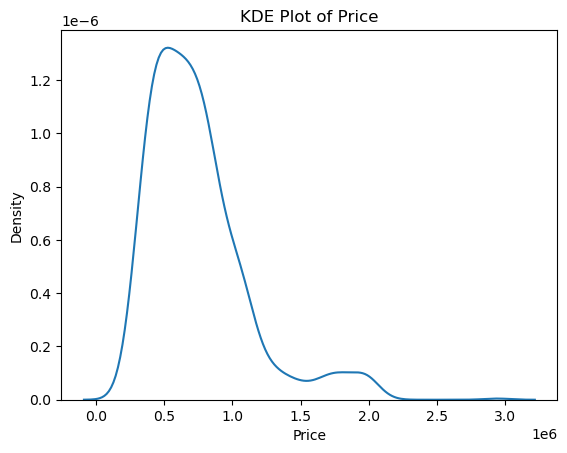

In [23]:
print(df["Price"].describe())
sns.kdeplot(data=df, x="Price")
plt.title("KDE Plot of Price")
plt.show()

           count          mean            std       min       25%        50%  \
Body_Type                                                                      
crossover   21.0  7.050952e+05   72849.780207  608000.0  638000.0   706000.0   
hatchback  484.0  5.339773e+05  173086.729837  188000.0  401750.0   509000.0   
muv         38.0  6.264211e+05  184093.488526  328000.0  489750.0   621500.0   
sedan      227.0  8.097841e+05  286736.770092  368000.0  598000.0   772000.0   
suv        206.0  1.176495e+06  417479.028217  559000.0  860000.0  1065000.0   

                 75%        max  
Body_Type                        
crossover   749000.0   883000.0  
hatchback   661000.0  1107000.0  
muv         738500.0  1091000.0  
sedan       968500.0  2941000.0  
suv        1491250.0  2100000.0  


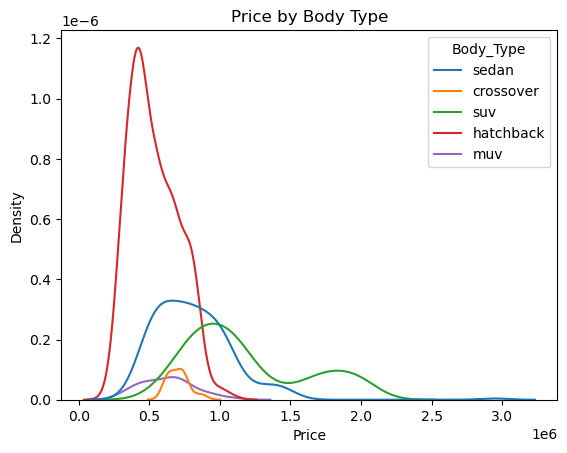

In [24]:
print(df.groupby("Body_Type")["Price"].describe())
sns.kdeplot(data=df, x="Price", hue="Body_Type")
plt.title("Price by Body Type")
plt.show()

The most expensive on average are SUVs then sedans. SUVs also have the most variance since their distribution is the widest and have the largest SD. And the KDE plot shows that most prices are skewed to the right.

In [25]:
RegPoS = smf.ols("Price ~ Seating_Capacity", data=df).fit()
print(RegPoS.summary())

                            OLS Regression Results                            
Dep. Variable:                  Price   R-squared:                       0.005
Model:                            OLS   Adj. R-squared:                  0.004
Method:                 Least Squares   F-statistic:                     5.075
Date:                Wed, 18 Mar 2026   Prob (F-statistic):             0.0245
Time:                        20:10:23   Log-Likelihood:                -13888.
No. Observations:                 976   AIC:                         2.778e+04
Df Residuals:                     974   BIC:                         2.779e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                       coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------
Intercept          4.39e+05   1.35e+05  

In [26]:
SeatCat = smf.ols("Price ~ C(Seating_Capacity)", data=df).fit()
print(SeatCat.summary())

                            OLS Regression Results                            
Dep. Variable:                  Price   R-squared:                       0.022
Model:                            OLS   Adj. R-squared:                  0.018
Method:                 Least Squares   F-statistic:                     5.397
Date:                Wed, 18 Mar 2026   Prob (F-statistic):           0.000267
Time:                        20:10:57   Log-Likelihood:                -13880.
No. Observations:                 976   AIC:                         2.777e+04
Df Residuals:                     971   BIC:                         2.779e+04
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                               coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------------
Intercept               

The slope coefficient is about 59270, meaning that for each additional seat, the price increases by about that much on average. When seating capacity is categorical, the prices do not increase in a consistent way. Thus, the relationship is not really linear.

In [27]:
df["Age"] =2026 -df["Make_Year"]
results = {}
results[1] = run_cv("Price ~ Age", df)
results[2] = run_cv("Price ~ Age + I(Age**2)", df)
results[3] = run_cv("Price ~ Age + I(Age**2) + I(Age**3)", df)
results[4] = run_cv("Price ~ Age + I(Age**2) + I(Age**3) + I(Age**4)", df)
print(results)

{1: 97600799685.98305, 2: 97624012506.91159, 3: 97059179666.99466, 4: 96614804677.32271}


Through cross-validation, the model with 4 powers of age has the lowest MSE, meaning that model is the best fit in the relationship between price and age. This means that adding polynomial terms improves the fit.

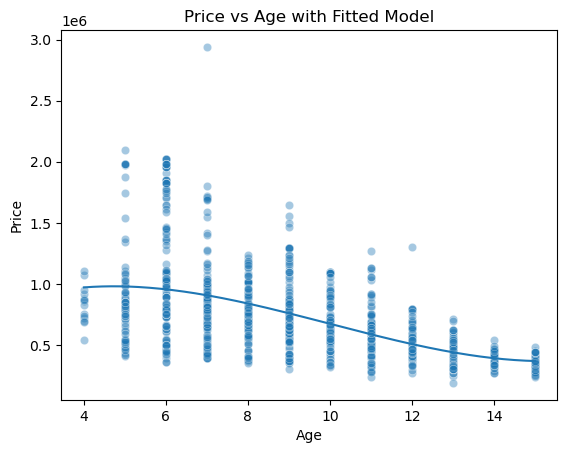

In [28]:
best_model = smf.ols("Price ~ Age + I(Age**2) + I(Age**3)", data=df).fit()
sns.scatterplot(data=df, x="Age", y="Price", alpha=0.4)
age_vals = np.linspace(df["Age"].min(), df["Age"].max(), 200)
pred_df = pd.DataFrame({"Age": age_vals})
pred_price = best_model.predict(pred_df)
plt.plot(age_vals, pred_price)
plt.title("Price vs Age with Fitted Model")
plt.show()

The plot shows that price usually decreases as age increases, which makes sense as older cars may be cheaper. The fitted model has a downward trend, however, there is still a lot of spread in prices, so the model does not fully explain the variation.

**Q4.** This question refers to the `heart_hw.csv` data. It contains three variables:

  - `y`: Whether the individual survived for three years, coded 0 for death and 1 for survival
  - `age`: Patient's age
  - `transplant`: labelled `control` for not receiving a transplant and labelled `treatment` for receiving a transplant

Since a heart transplant is a dangerous operation and even people who successfully get heart transplants might suffer later complications, we want to look at whether a group of transplant recipients tends to survive longer than a comparison group who does not get the procedure.

1. Compute (a) the proportion of people who survive in the control group and (b) in the treatment group. Compute (b) minus (a) as the average treatment effect (ATE). What is the ATE on three-year survival for heart transplant interventions?
2. Regress `y` on `transplant` using a linear model with a constant. Compare the intercept and transplant coefficient to the numbers you computed in part 1. 
3. Regress `y` on transplant and age. How does the coefficient on transplant change when you control for age?What do the intercept and slope represent? Plot the predicted probability of survival by age, and add a dashed horizontal line for the ATE from part 1. For what ages is the ATE over- or under-estimating the impact of a transplant?
4. Now, include `transplant`, `age`, and `transplant * age` as controls. Repeat your analysis from part 3. How does allowing age and transplant to interact change your predictions? What pattern do you notice?
5. Use 10-fold cross validation to evaluate the predictive accuracy of these models. 
6. Imagine this model is used to prioritize transplant access. What are your concerns about model construction and deployment?


In [30]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import statsmodels.formula.api as smf
from sklearn.model_selection import KFold
from sklearn.metrics import mean_squared_error
import numpy as np

df = pd.read_csv("./data/heart_hw.csv")

In [31]:
survival_rates =df.groupby("transplant")["y"].mean()
print(survival_rates)
ate =survival_rates["treatment"]- survival_rates["control"]
print("ATE:", ate)

transplant
control      0.117647
treatment    0.347826
Name: y, dtype: float64
ATE: 0.23017902813299232


The survival rate in teh control group is about 0.118, while survival rate in the treatment group is 0.348. Average is 0.23, making receiving a transplant corresponds to about 0.23 point increase in 3 year survival.

In [32]:
RegTran = smf.ols("y ~ C(transplant)", data=df).fit()
print(RegTran.summary())

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.059
Model:                            OLS   Adj. R-squared:                  0.050
Method:                 Least Squares   F-statistic:                     6.354
Date:                Wed, 18 Mar 2026   Prob (F-statistic):             0.0133
Time:                        20:47:03   Log-Likelihood:                -59.591
No. Observations:                 103   AIC:                             123.2
Df Residuals:                     101   BIC:                             128.5
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                                 coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------------
Intercept           

The intercept is about 0.118 which matches the survival rate of the control group. The coefficient on transplant which is about 0.230 matches the ATE from part 1.     

In [33]:
RegTA = smf.ols("y ~ C(transplant) + age", data=df).fit()
print(RegTA.summary())

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.147
Model:                            OLS   Adj. R-squared:                  0.130
Method:                 Least Squares   F-statistic:                     8.602
Date:                Wed, 18 Mar 2026   Prob (F-statistic):           0.000357
Time:                        20:47:43   Log-Likelihood:                -54.558
No. Observations:                 103   AIC:                             115.1
Df Residuals:                     100   BIC:                             123.0
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                                 coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------------
Intercept           

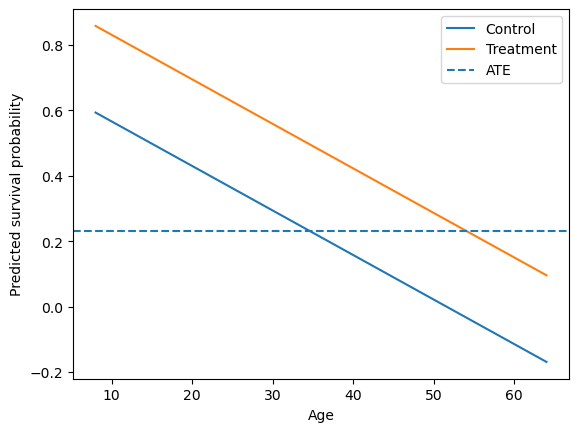

In [34]:
grid_a = pd.DataFrame({"age": np.linspace(df["age"].min(), df["age"].max(), 100)})
c_preds = grid_a.copy()
c_preds["transplant"] = "control"
c_preds["pred"] = RegTA.predict(c_preds)
t_preds = grid_a.copy()
t_preds["transplant"] = "treatment"
t_preds["pred"] = RegTA.predict(t_preds)
plt.plot(c_preds["age"],c_preds["pred"], label="Control")
plt.plot(t_preds["age"], t_preds["pred"],label="Treatment")
plt.axhline(y=ate, linestyle="--",label="ATE")
plt.xlabel("Age")
plt.ylabel("Predicted survival probability")
plt.legend()
plt.show()

After controlling age, the transplant coefficient increased slightly to about 0.265, meaning that there is a slightly larger benefit of a transplant. The intercept represents precdicted survival for the control group at 0 age, and the age coefficient is about -0.014, displaying that survival decreases as age increases. Based on the plot, the gap between treatment and control is pretty constant across age.

In [35]:
inter = smf.ols("y ~ C(transplant) * age", data=df).fit()
print(inter.summary())

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.172
Model:                            OLS   Adj. R-squared:                  0.147
Method:                 Least Squares   F-statistic:                     6.839
Date:                Wed, 18 Mar 2026   Prob (F-statistic):           0.000310
Time:                        20:50:36   Log-Likelihood:                -53.033
No. Observations:                 103   AIC:                             114.1
Df Residuals:                      99   BIC:                             124.6
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                                     coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------------------
Intercept   

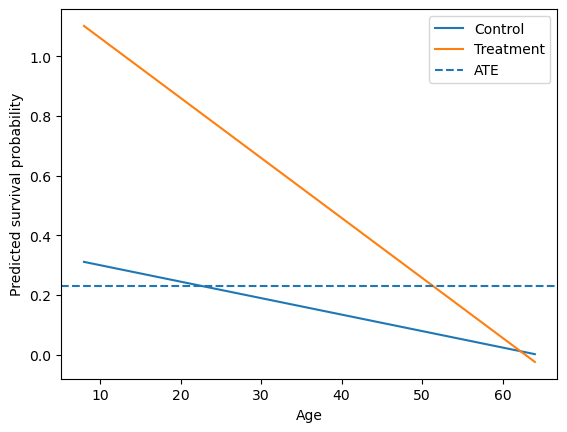

In [38]:
c_preds2=grid_a.copy()
c_preds2["transplant"] = "control"
c_preds2["pred"] = inter.predict(c_preds2)
t_preds2 = grid_a.copy()
t_preds2["transplant"] = "treatment"
t_preds2["pred"] = inter.predict(t_preds2)
plt.plot(c_preds2["age"],c_preds2["pred"], label="Control")
plt.plot(t_preds2["age"], t_preds2["pred"],label="Treatment")
plt.axhline(y=ate, linestyle="--",label="ATE")
plt.xlabel("Age")
plt.ylabel("Predicted survival probability")
plt.legend()
plt.show()

When including the interaction between transplant and age, the effect of transplant depends on age. This negative interaction shows that the benefit of a transplant decreases as age increases. Based on the plot, the treatment and control lines are not parallel anymore, which means that younger patients benefit more from a transplant, while the effect becomes smaller for older patients. 

In [40]:
def run_cv(formula, data, k=5):
    kf = KFold(n_splits=k, shuffle=True, random_state=1)
    errors = []
    for train, test in kf.split(data):
        train_data = data.iloc[train]
        test_data = data.iloc[test]
        model = smf.ols(formula, data=train_data).fit()
        predictions = model.predict(test_data)
        mse = mean_squared_error(test_data["y"], predictions)
        errors.append(mse)
    return sum(errors) / len(errors)
cv1 = run_cv("y ~ C(transplant)", df)
cv2 = run_cv("y ~ C(transplant) + age", df)
cv3 = run_cv("y ~ C(transplant) * age", df)
print("First model:", cv1)
print("Second model:", cv2)
print("Third model:", cv3)

First model: 0.1929853497158772
Second model: 0.17999306096190457
Third model: 0.18376276055142665


With cross-validation, the model with transplant and age has the lowest MSE with 0.18 compared to the simpler model and the interaction model. This may mean that adding age improves predictive performancem but adding the interaction term doesn't do much. 